In [1]:
# Run this once to install all required packages
!pip install pandas numpy scikit-learn xgboost lightgbm catboost optuna imbalanced-learn joblib matplotlib seaborn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2


In [2]:
import os
import sys
import json
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

try:
    import xgboost as xgb
except ImportError:
    xgb = None
try:
    import lightgbm as lgb
except ImportError:
    lgb = None
try:
    import catboost as cb
except ImportError:
    cb = None
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

warnings.filterwarnings('ignore')
print("✅ All imports loaded successfully!")

e:\downloads\Multiple-Disease-Prediction-Webapp-main\Multiple-Disease-Prediction-Webapp-main\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports loaded successfully!


In [3]:
print(f"📊 XGBoost available: {xgb is not None}")
print(f"📊 LightGBM available: {lgb is not None}")
print(f"📊 CatBoost available: {cb is not None}")
print(f"📊 Optuna available: {OPTUNA_AVAILABLE}")

📊 XGBoost available: True
📊 LightGBM available: True
📊 CatBoost available: True
📊 Optuna available: True


In [4]:
DATA_DIR = Path("database")
MODELS_DIR = Path("models")
os.makedirs(MODELS_DIR, exist_ok=True)

DISEASE_CONFIGS = {
    "diabetes": {
        "file": "diabetes.csv",
        "target": "Outcome",
        "drop_cols": [],
    },
    "heart": {
        "file": "heart.csv",
        "target": "target",
        "drop_cols": [],
    },
    "breast": {
        "file": "breast-cancer.csv",
        "target": "diagnosis",
        "drop_cols": ["id"],
    },
}

print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Models directory: {MODELS_DIR}")
print(f"📋 Diseases to train: {list(DISEASE_CONFIGS.keys())}")

📁 Data directory: database
📁 Models directory: models
📋 Diseases to train: ['diabetes', 'heart', 'breast']


In [5]:
def get_available_diseases() -> List[str]:
    """Return list of diseases for which the dataset file exists."""
    available = []
    for disease, config in DISEASE_CONFIGS.items():
        file_path = DATA_DIR / config["file"]
        if file_path.exists():
            available.append(disease)
        else:
            print(f"⚠️ Dataset file {file_path} not found. Skipping {disease}.")
    return available

def load_dataset(disease: str) -> Tuple[pd.DataFrame, pd.Series]:
    """Load dataset, handle target encoding."""
    config = DISEASE_CONFIGS[disease]
    file_path = DATA_DIR / config["file"]
    df = pd.read_csv(file_path)
    print(f"📊 Loaded {disease}: {df.shape[0]} rows, {df.shape[1]} columns")
    
    if config.get("drop_cols"):
        df = df.drop(columns=[c for c in config["drop_cols"] if c in df.columns], errors='ignore')
    
    target_col = config["target"]
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    if disease == "breast":
        y = y.map({'M': 1, 'B': 0}).astype(int)
    else:
        if y.dtype == 'object' or y.dtype.name == 'category':
            le = LabelEncoder()
            y = le.fit_transform(y)
        else:
            y = y.astype(int)
    
    return X, y

def preprocess_data(X: pd.DataFrame, fit: bool = True, preprocessor=None) -> Tuple[pd.DataFrame, Any]:
    """Smart preprocessing: detect numeric vs. categorical columns."""
    for col in X.columns:
        if X[col].dtype == 'object':
            converted = pd.to_numeric(X[col], errors='coerce')
            if converted.isnull().sum() < len(converted) * 0.5:
                X[col] = converted
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"   📊 Detected numeric: {len(num_cols)}, categorical: {len(cat_cols)}")
    
    if fit:
        transformers = []
        if num_cols:
            transformers.append(('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_cols))
        if cat_cols:
            transformers.append(('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), cat_cols))
        preprocessor = ColumnTransformer(transformers, remainder='drop')
        X_transformed = preprocessor.fit_transform(X)
        feature_names = []
        if num_cols:
            feature_names.extend(num_cols)
        if cat_cols:
            ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
            cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
            feature_names.extend(cat_feature_names)
        preprocessor.feature_names_ = feature_names
        return X_transformed, preprocessor
    else:
        if preprocessor is None:
            raise ValueError("Preprocessor required.")
        X_transformed = preprocessor.transform(X)
        return X_transformed, preprocessor

print("✅ Utility functions loaded!")

✅ Utility functions loaded!


In [11]:
# Run this cell to fix the LightGBM compatibility issue
# This patches both _LGBMCheckXY and _LGBMCheckArray

import lightgbm as lgb
import sklearn
from sklearn.utils import check_array, check_X_y

print(f"Scikit-learn version: {sklearn.__version__}")
print(f"LightGBM version: {lgb.__version__}")

# Monkey patch LightGBM's check functions
try:
    import lightgbm.sklearn as lgb_sklearn
    
    # Save original functions
    original_check_xy = lgb_sklearn._LGBMCheckXY
    original_check_array = lgb_sklearn._LGBMCheckArray
    
    # Define patched versions
    def patched_check_xy(X, y, **kwargs):
        kwargs.pop('force_all_finite', None)
        return check_X_y(X, y, **kwargs)
    
    def patched_check_array(X, **kwargs):
        kwargs.pop('force_all_finite', None)
        return check_array(X, **kwargs)
    
    # Apply patches
    lgb_sklearn._LGBMCheckXY = patched_check_xy
    lgb_sklearn._LGBMCheckArray = patched_check_array
    
    print("✅ LightGBM patch applied successfully!")
except Exception as e:
    print(f"❌ Patch failed: {e}")
    print("Try the alternative fix below.")

Scikit-learn version: 1.9.0
LightGBM version: 4.1.0
✅ LightGBM patch applied successfully!


In [12]:
def train_single_disease(disease: str) -> Dict:
    """Train a model for one disease and return metrics."""
    print(f"\n{'='*60}")
    print(f"🔬 TRAINING: {disease.upper()}")
    print(f"{'='*60}")
    
    # Load data
    X, y = load_dataset(disease)
    print(f"   Data shape: {X.shape}, Classes: {np.unique(y)}")
    print(f"   Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
    
    # Split
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    print(f"   Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
    
    # Preprocess
    X_train_transformed, preprocessor = preprocess_data(X_train, fit=True)
    X_val_transformed, _ = preprocess_data(X_val, fit=False, preprocessor=preprocessor)
    X_test_transformed, _ = preprocess_data(X_test, fit=False, preprocessor=preprocessor)
    print(f"   Features after preprocessing: {X_train_transformed.shape[1]}")
    
    # Define models
    models = {}
    if xgb is not None:
        models['XGBoost'] = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss', use_label_encoder=False)
    models['RandomForest'] = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    models['LogisticRegression'] = LogisticRegression(max_iter=1000, random_state=42)
    if lgb is not None:
        models['LightGBM'] = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
    if cb is not None:
        models['CatBoost'] = cb.CatBoostClassifier(iterations=200, random_state=42, verbose=0)
    
    # Train and evaluate
    results = {}
    best_model = None
    best_score = -1
    
    for name, model in models.items():
        print(f"\n   📊 Training {name}...")
        if len(np.unique(y_train)) == 2 and min(np.bincount(y_train)) / len(y_train) < 0.4:
            smote = SMOTE(random_state=42)
            X_train_res, y_train_res = smote.fit_resample(X_train_transformed, y_train)
        else:
            X_train_res, y_train_res = X_train_transformed, y_train
        
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_transformed)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'weighted')
        rec = recall_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'weighted')
        f1 = f1_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'weighted')
        roc = roc_auc_score(y_test, model.predict_proba(X_test_transformed)[:, 1]) if len(np.unique(y)) == 2 else None
        
        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': roc,
            'model': model
        }
        
        print(f"      ✅ Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        if roc:
            print(f"      ROC-AUC: {roc:.4f}")
        
        if f1 > best_score:
            best_score = f1
            best_model = model
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"🏆 BEST MODEL: {best_model.__class__.__name__} with F1: {best_score:.4f}")
    print(f"{'='*60}")
    
    return {
        'disease': disease,
        'results': results,
        'best_model': best_model,
        'best_score': best_score,
        'X_test': X_test_transformed,
        'y_test': y_test,
        'preprocessor': preprocessor
    }

In [13]:
def display_metrics(results: Dict):
    """Display metrics table for all models."""
    df = pd.DataFrame()
    for model_name, metrics in results.items():
        df[model_name] = [
            metrics['accuracy'],
            metrics['precision'],
            metrics['recall'],
            metrics['f1'],
            metrics['roc_auc'] if metrics['roc_auc'] else 'N/A'
        ]
    df.index = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    return df

# Train all diseases
all_training_results = {}
diseases = get_available_diseases()

for disease in diseases:
    result = train_single_disease(disease)
    all_training_results[disease] = result
    
    # Display metrics table
    print(f"\n📊 METRICS SUMMARY for {disease.upper()}:")
    df_metrics = display_metrics(result['results'])
    display(df_metrics)


🔬 TRAINING: DIABETES
📊 Loaded diabetes: 768 rows, 9 columns
   Data shape: (768, 8), Classes: [0 1]
   Class distribution: {0: 500, 1: 268}
   Split: Train=537, Val=115, Test=116
   📊 Detected numeric: 8, categorical: 0
   📊 Detected numeric: 8, categorical: 0
   📊 Detected numeric: 8, categorical: 0
   Features after preprocessing: 8

   📊 Training XGBoost...
      ✅ Accuracy: 0.7672, Precision: 0.7188, Recall: 0.5610, F1: 0.6301
      ROC-AUC: 0.7984

   📊 Training RandomForest...
      ✅ Accuracy: 0.7586, Precision: 0.6757, Recall: 0.6098, F1: 0.6410
      ROC-AUC: 0.8332

   📊 Training LogisticRegression...
      ✅ Accuracy: 0.7672, Precision: 0.6842, Recall: 0.6341, F1: 0.6582
      ROC-AUC: 0.8455

   📊 Training LightGBM...
      ✅ Accuracy: 0.7241, Precision: 0.6364, Recall: 0.5122, F1: 0.5676
      ROC-AUC: 0.7743

   📊 Training CatBoost...
      ✅ Accuracy: 0.7328, Precision: 0.6471, Recall: 0.5366, F1: 0.5867
      ROC-AUC: 0.8289

🏆 BEST MODEL: LogisticRegression with F1: 0

,XGBoost,RandomForest,LogisticRegression,LightGBM,CatBoost
Accuracy,0.767241,0.758621,0.767241,0.724138,0.732759
Precision,0.718750,0.675676,0.684211,0.636364,0.647059
Recall,0.560976,0.609756,0.634146,0.512195,0.536585
F1-Score,0.630137,0.641026,0.658228,0.567568,0.586667
ROC-AUC,0.798374,0.833171,0.845528,0.774309,0.828943



🔬 TRAINING: HEART
📊 Loaded heart: 1025 rows, 14 columns
   Data shape: (1025, 13), Classes: [0 1]
   Class distribution: {0: 499, 1: 526}
   Split: Train=717, Val=154, Test=154
   📊 Detected numeric: 13, categorical: 0
   📊 Detected numeric: 13, categorical: 0
   📊 Detected numeric: 13, categorical: 0
   Features after preprocessing: 13

   📊 Training XGBoost...
      ✅ Accuracy: 0.9805, Precision: 1.0000, Recall: 0.9620, F1: 0.9806
      ROC-AUC: 0.9884

   📊 Training RandomForest...
      ✅ Accuracy: 0.9675, Precision: 1.0000, Recall: 0.9367, F1: 0.9673
      ROC-AUC: 0.9983

   📊 Training LogisticRegression...
      ✅ Accuracy: 0.7987, Precision: 0.7553, Recall: 0.8987, F1: 0.8208
      ROC-AUC: 0.9072

   📊 Training LightGBM...
      ✅ Accuracy: 0.9805, Precision: 1.0000, Recall: 0.9620, F1: 0.9806
      ROC-AUC: 1.0000

   📊 Training CatBoost...
      ✅ Accuracy: 0.9675, Precision: 0.9744, Recall: 0.9620, F1: 0.9682
      ROC-AUC: 0.9965

🏆 BEST MODEL: XGBClassifier with F1: 0.98

,XGBoost,RandomForest,LogisticRegression,LightGBM,CatBoost
Accuracy,0.980519,0.967532,0.798701,0.980519,0.967532
Precision,1.000000,1.000000,0.755319,1.000000,0.974359
Recall,0.962025,0.936709,0.898734,0.962025,0.962025
F1-Score,0.980645,0.967320,0.820809,0.980645,0.968153
ROC-AUC,0.988354,0.998312,0.907173,1.000000,0.996456



🔬 TRAINING: BREAST
📊 Loaded breast: 569 rows, 32 columns
   Data shape: (569, 30), Classes: [0 1]
   Class distribution: {0: 357, 1: 212}
   Split: Train=398, Val=85, Test=86
   📊 Detected numeric: 30, categorical: 0
   📊 Detected numeric: 30, categorical: 0
   📊 Detected numeric: 30, categorical: 0
   Features after preprocessing: 30

   📊 Training XGBoost...
      ✅ Accuracy: 0.9884, Precision: 1.0000, Recall: 0.9688, F1: 0.9841
      ROC-AUC: 1.0000

   📊 Training RandomForest...
      ✅ Accuracy: 0.9884, Precision: 1.0000, Recall: 0.9688, F1: 0.9841
      ROC-AUC: 0.9994

   📊 Training LogisticRegression...
      ✅ Accuracy: 0.9884, Precision: 0.9697, Recall: 1.0000, F1: 0.9846
      ROC-AUC: 0.9988

   📊 Training LightGBM...
      ✅ Accuracy: 0.9884, Precision: 1.0000, Recall: 0.9688, F1: 0.9841
      ROC-AUC: 1.0000

   📊 Training CatBoost...
      ✅ Accuracy: 0.9767, Precision: 1.0000, Recall: 0.9375, F1: 0.9677
      ROC-AUC: 1.0000

🏆 BEST MODEL: LogisticRegression with F1: 0

,XGBoost,RandomForest,LogisticRegression,LightGBM,CatBoost
Accuracy,0.988372,0.988372,0.988372,0.988372,0.976744
Precision,1.000000,1.000000,0.969697,1.000000,1.000000
Recall,0.968750,0.968750,1.000000,0.968750,0.937500
F1-Score,0.984127,0.984127,0.984615,0.984127,0.967742
ROC-AUC,1.000000,0.999421,0.998843,1.000000,1.000000


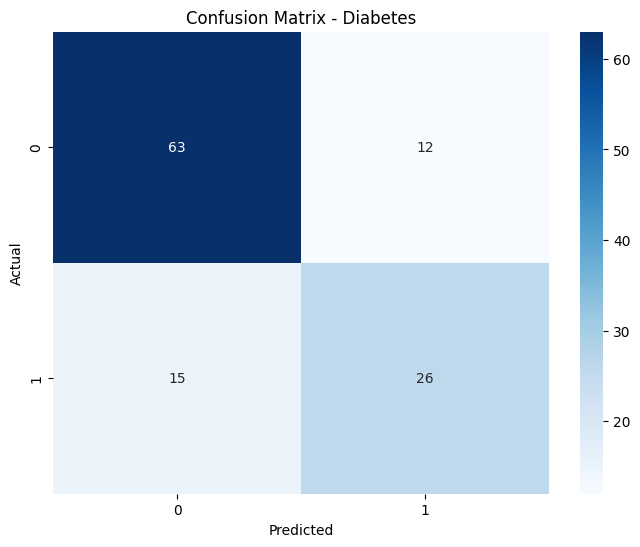

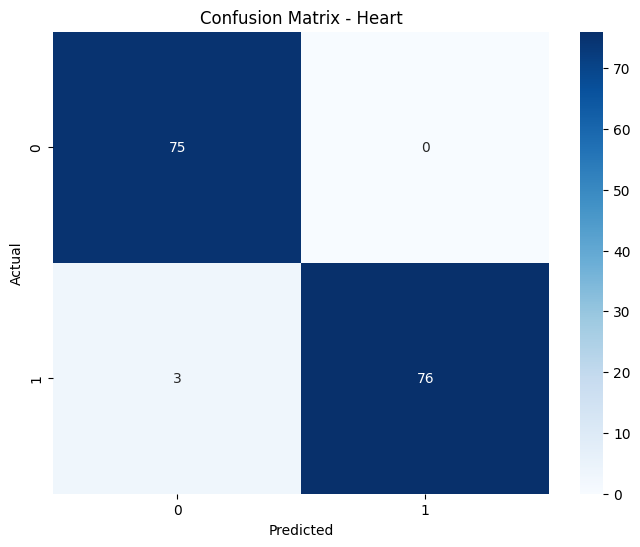

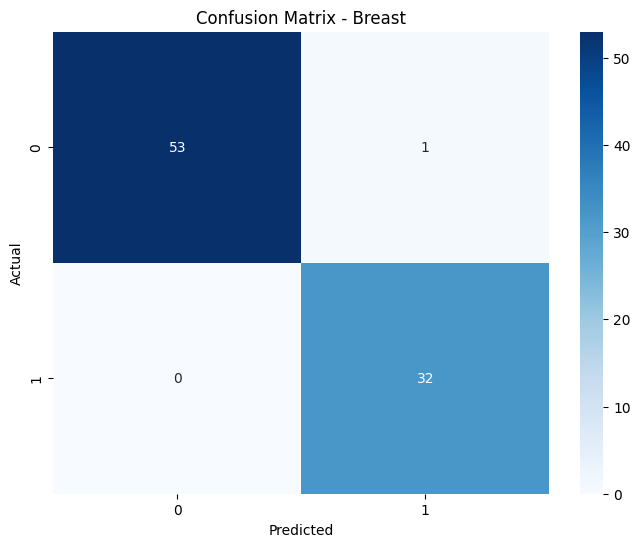

In [14]:
def plot_confusion_matrix(disease: str, result: Dict):
    """Plot confusion matrix for the best model."""
    best_model = result['best_model']
    X_test = result['X_test']
    y_test = result['y_test']
    
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {disease.capitalize()}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot for each disease
for disease, result in all_training_results.items():
    plot_confusion_matrix(disease, result)

In [15]:
for disease, result in all_training_results.items():
    best_model = result['best_model']
    preprocessor = result['preprocessor']
    
    model_path = MODELS_DIR / f"{disease}_model.pkl"
    preprocessor_path = MODELS_DIR / f"{disease}_preprocessor.pkl"
    
    joblib.dump(best_model, model_path)
    joblib.dump(preprocessor, preprocessor_path)
    
    print(f"✅ Saved {disease} model to {model_path}")
    print(f"✅ Saved {disease} preprocessor to {preprocessor_path}")

✅ Saved diabetes model to models\diabetes_model.pkl
✅ Saved diabetes preprocessor to models\diabetes_preprocessor.pkl
✅ Saved heart model to models\heart_model.pkl
✅ Saved heart preprocessor to models\heart_preprocessor.pkl
✅ Saved breast model to models\breast_model.pkl
✅ Saved breast preprocessor to models\breast_preprocessor.pkl


In [16]:
summary = {}
for disease, result in all_training_results.items():
    summary[disease] = {
        'best_model': result['best_model'].__class__.__name__,
        'best_f1_score': result['best_score'],
        'metrics': {k: {kk: vv for kk, vv in v.items() if kk != 'model'} for k, v in result['results'].items()}
    }

with open(MODELS_DIR / "training_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("📊 Training summary saved to models/training_summary.json")
print("\n📋 SUMMARY:")
for disease, data in summary.items():
    print(f"\n🔬 {disease.upper()}:")
    print(f"   Best Model: {data['best_model']}")
    print(f"   Best F1: {data['best_f1_score']:.4f}")

📊 Training summary saved to models/training_summary.json

📋 SUMMARY:

🔬 DIABETES:
   Best Model: LogisticRegression
   Best F1: 0.6582

🔬 HEART:
   Best Model: XGBClassifier
   Best F1: 0.9806

🔬 BREAST:
   Best Model: LogisticRegression
   Best F1: 0.9846


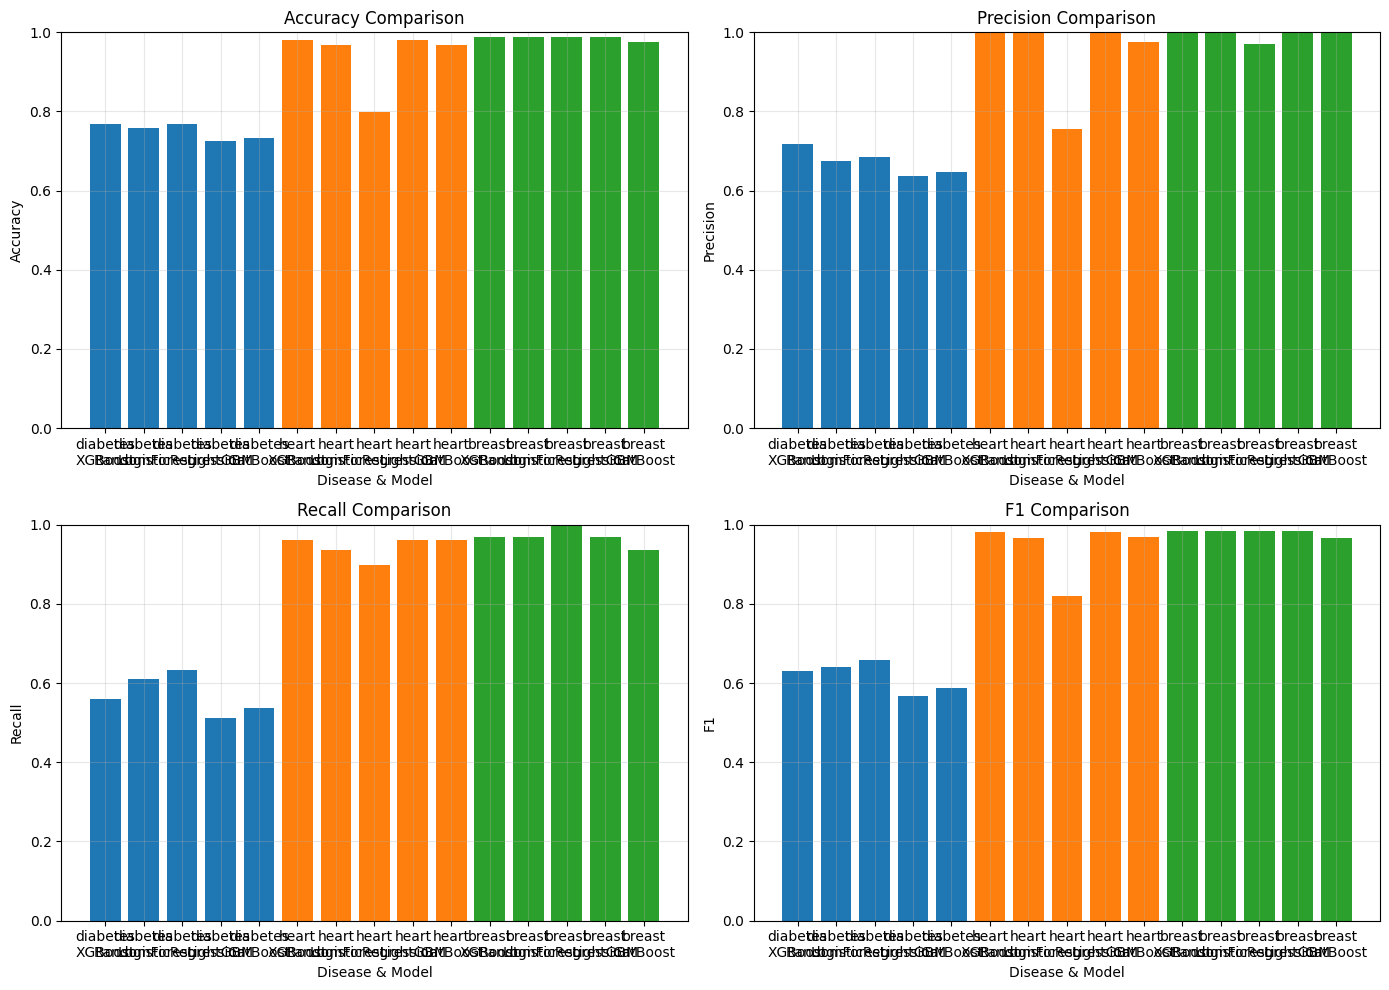

In [17]:
def plot_metrics_comparison(all_results: Dict):
    """Plot comparison of metrics across diseases."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        for disease, result in all_results.items():
            models = []
            scores = []
            for model_name, metrics_dict in result['results'].items():
                models.append(model_name)
                scores.append(metrics_dict[metric])
            ax.bar([f"{disease}\n{m}" for m in models], scores)
        ax.set_title(f'{metric.capitalize()} Comparison')
        ax.set_ylabel(metric.capitalize())
        ax.set_xlabel('Disease & Model')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_metrics_comparison(all_training_results)

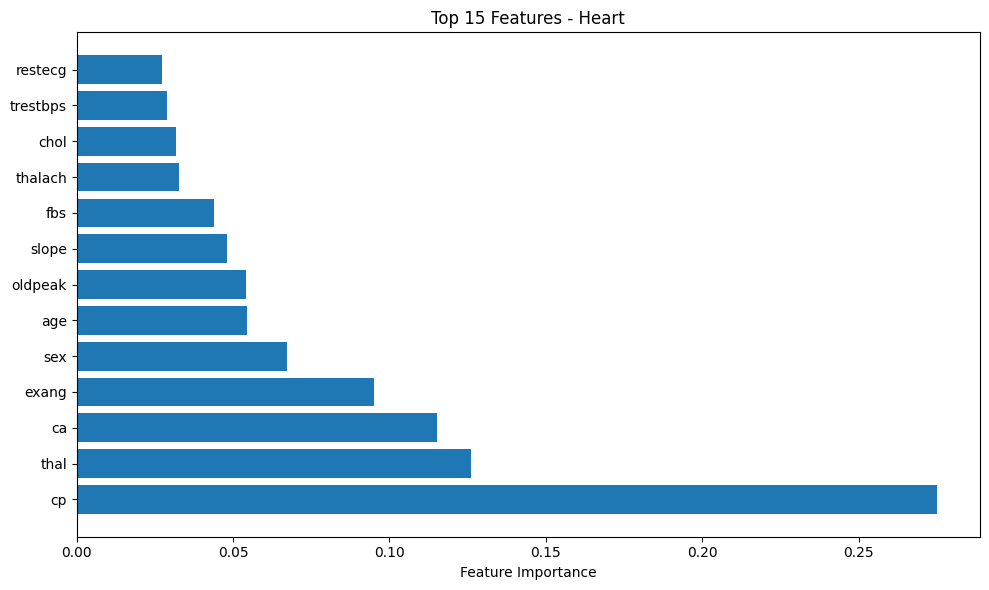

In [18]:
def plot_feature_importance(disease: str, result: Dict):
    """Plot feature importance for the best model if available."""
    best_model = result['best_model']
    preprocessor = result['preprocessor']
    
    if hasattr(best_model, 'feature_importances_'):
        feature_names = preprocessor.feature_names_ if hasattr(preprocessor, 'feature_names_') else [f'Feature_{i}' for i in range(best_model.feature_importances_.shape[0])]
        importance = best_model.feature_importances_
        
        # Sort by importance
        indices = np.argsort(importance)[::-1][:15]  # Top 15
        plt.figure(figsize=(10, 6))
        plt.barh([feature_names[i] for i in indices], importance[indices])
        plt.xlabel('Feature Importance')
        plt.title(f'Top 15 Features - {disease.capitalize()}')
        plt.tight_layout()
        plt.show()

# Plot for each disease
for disease, result in all_training_results.items():
    plot_feature_importance(disease, result)

In [19]:
print("\n" + "="*70)
print("🏁 TRAINING COMPLETE!")
print("="*70)

for disease, data in summary.items():
    print(f"\n🔬 {disease.upper()}:")
    print(f"   ✅ Best Model: {data['best_model']}")
    print(f"   ✅ Best F1-Score: {data['best_f1_score']:.4f}")
    print(f"   📊 Metrics:")
    for model, metrics in data['metrics'].items():
        print(f"      {model}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

print("\n" + "="*70)
print("📁 Models saved to:", MODELS_DIR)
print("📁 Training summary saved to:", MODELS_DIR / "training_summary.json")
print("="*70)


🏁 TRAINING COMPLETE!

🔬 DIABETES:
   ✅ Best Model: LogisticRegression
   ✅ Best F1-Score: 0.6582
   📊 Metrics:
      XGBoost: Acc=0.7672, F1=0.6301
      RandomForest: Acc=0.7586, F1=0.6410
      LogisticRegression: Acc=0.7672, F1=0.6582
      LightGBM: Acc=0.7241, F1=0.5676
      CatBoost: Acc=0.7328, F1=0.5867

🔬 HEART:
   ✅ Best Model: XGBClassifier
   ✅ Best F1-Score: 0.9806
   📊 Metrics:
      XGBoost: Acc=0.9805, F1=0.9806
      RandomForest: Acc=0.9675, F1=0.9673
      LogisticRegression: Acc=0.7987, F1=0.8208
      LightGBM: Acc=0.9805, F1=0.9806
      CatBoost: Acc=0.9675, F1=0.9682

🔬 BREAST:
   ✅ Best Model: LogisticRegression
   ✅ Best F1-Score: 0.9846
   📊 Metrics:
      XGBoost: Acc=0.9884, F1=0.9841
      RandomForest: Acc=0.9884, F1=0.9841
      LogisticRegression: Acc=0.9884, F1=0.9846
      LightGBM: Acc=0.9884, F1=0.9841
      CatBoost: Acc=0.9767, F1=0.9677

📁 Models saved to: models
📁 Training summary saved to: models\training_summary.json
